In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("vad.csv")

# Parse timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort just in case
df = df.sort_values("Timestamp")

df.head()

,Timestamp,SpeechProbability,IsSpeech
0,2026-06-22 18:23:52.937,0.0602,False
1,2026-06-22 18:23:52.952,0.0254,False
2,2026-06-22 18:23:52.953,0.0176,False
3,2026-06-22 18:23:53.037,0.0122,False
4,2026-06-22 18:23:53.037,0.0067,False


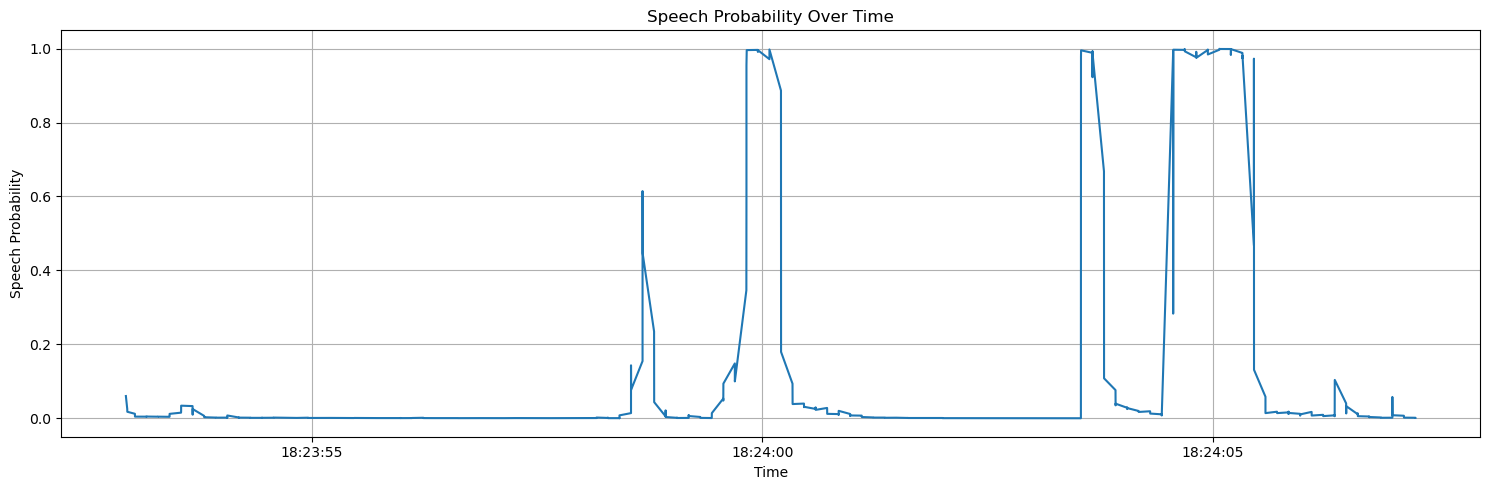

In [12]:
plt.figure(figsize=(15, 5))
plt.plot(df["Timestamp"], df["SpeechProbability"])
plt.title("Speech Probability Over Time")
plt.xlabel("Time")
plt.ylabel("Speech Probability")
plt.grid(True)
plt.tight_layout()
plt.show()

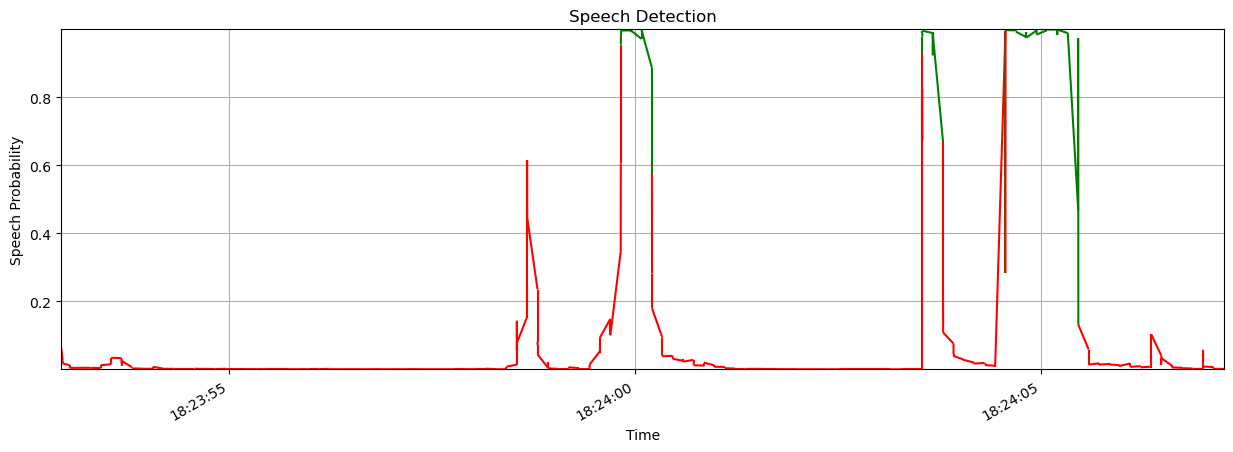

In [13]:
from matplotlib.collections import LineCollection
import numpy as np
import matplotlib.dates as mdates

x = mdates.date2num(df["Timestamp"])
y = df["SpeechProbability"].values

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

colors = np.where(df["IsSpeech"][:-1], "green", "red")

lc = LineCollection(segments, colors=colors, linewidths=1.5)

fig, ax = plt.subplots(figsize=(15, 5))
ax.add_collection(lc)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())

ax.xaxis_date()
fig.autofmt_xdate()

ax.set_title("Speech Detection")
ax.set_xlabel("Time")
ax.set_ylabel("Speech Probability")
ax.grid(True)

plt.show()

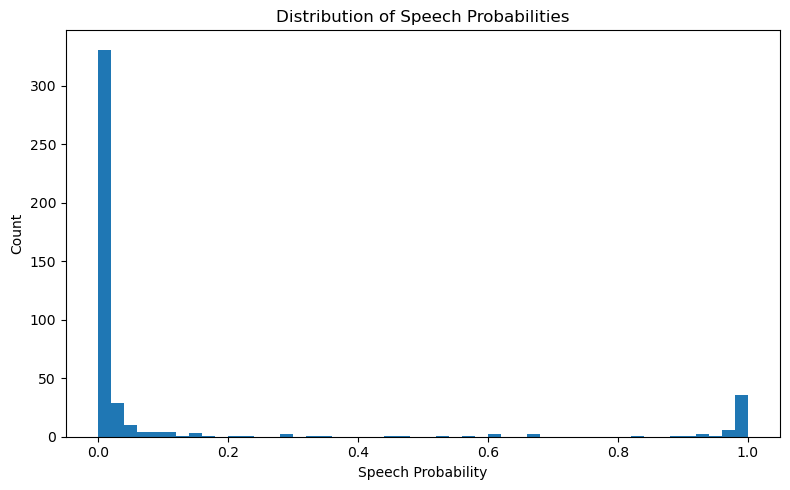

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df["SpeechProbability"], bins=50)
plt.title("Distribution of Speech Probabilities")
plt.xlabel("Speech Probability")
plt.ylabel("Count")
plt.tight_layout()
plt.show()